<a href="https://colab.research.google.com/github/Akashkumar12/AI-ML/blob/main/Copy_of_U2_MH2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Perform customer segmentation using bank data into distinct categories based on their behavioral patterns

## Learning Objectives

At the end of the experiment, you will be able to:

* Understand clustering
* Find groups or clusters using K-means algorithm
* Visualize the high-dimensional data to low-dimensional data (2D) by applying t-SNE algorithm

In [1]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Customer_Segmentation.mp4" type="video/mp4">
</video>
""")

## Domain Information

- **Customer segmentation** refers to the process of dividing a set of potential customers into groups (or segments) based on shared attributes, interests, and behaviors.
- One of the key pain points for bank marketing team is to know their customers and identify their needs.
- For this mini-hackathon, we will use the popular **K-Means clustering** algorithm to segment customers based on their behavior from the bank data. The basic concept is that consumers who share common traits would respond to marketing communication in a similar way so that the bank marketing team can reach out to each group in a relevant and effective way.

## Dataset

### Description

The dataset chosen for this mini hackathon is the behavior of customers in the bank for 6 months, this dataset is made up of 13 features.

**Attribute Information**

- **CUSTID:** Identification of Credit Cardholder
- **BALANCE:** Balance amount left in customer's account to make purchases
- **PURCHASES:** Amount of purchases made from the account
- **INSTALLMENTS_PURCHASES:** Amount of purchase done in installment
- **CASH_ADVANCE:** Cash in advance given by the user
- **PURCHASES_FREQUENCY:** How frequently the Purchases are being made score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **CASH_ADVANCE_FREQUENCY:** How frequently the cash in advance being paid
- **CASH_ADVANCE_TRX:** Number of Transactions made with "Cash in Advance"
- **CREDIT_LIMIT:** Limit of Credit Card for user
- **PAYMENTS:** Amount of Payment done by a user
- **MINIMUM_PAYMENTS:** Minimum amount of payments made by a user
- **PRC_FULL_PAYMENT:** Percent of full payment paid by a user
- **TENURE:** Tenure of credit card service for user

**Note:** The currency values mentioned above are in "dollars"

## Grading = 10 Marks

## Setup Steps

In [ ]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH2_Customer_Segmentation" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Marketing_data_clustering.csv")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### Importing Required Packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

## **Stage 1:** Data Pre-Processing (2 Marks)

- Replace the missing values in any other column appropriately with mean / median / mode.

  Hint: Use pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function to replace the missing values

- Perform correlation on the data features and remove highly correlated features from the data
  
  Hint: Use pandas [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

- Drop any unwanted columns
  
  Hint: Use pandas [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

- Perform `StandardScaler()` on the data features
  
  Hint: Use Sklearns [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



In [ ]:
df = pd.read_csv('Marketing_data_clustering.csv')

# Drop CUST_ID as it is an identifier and not a feature
df.drop('CUST_ID', axis=1, inplace=True)

# Handle missing values: Fill numerical missing values with the mean
# Checking for missing values
# print(df.isnull().sum())
# From previous runs, 'MINIMUM_PAYMENTS' and 'CREDIT_LIMIT' have missing values.
# Fill with mean as they are numerical features.
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(), inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean(), inplace=True)

# Perform correlation analysis and remove highly correlated features
# Calculate the correlation matrix
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

# Drop highly correlated features
df_processed = df.drop(columns=to_drop)

# Perform StandardScaler on the data features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)

# Convert the scaled array back to a DataFrame for easier handling, keeping column names
df_scaled = pd.DataFrame(df_scaled, columns=df_processed.columns)

print("Shape of original data:", df.shape)
print("Shape of processed data after dropping correlated features:", df_processed.shape)
print("First 5 rows of scaled data:")
display(df_scaled.head())

Shape of original data: (2994, 12)
Shape of processed data after dropping correlated features: (2994, 11)
First 5 rows of scaled data:


/tmp/ipykernel_4474/1526218860.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean(), inplace=True)
/tmp/ipykernel_4474/1526218860.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.133600,-0.632613,-0.317151,-0.641837,-0.605044,-0.795323,-0.904793,-0.881709,-0.943177,-0.414442,0.0
1,-0.376303,-0.811660,-0.689393,-0.641837,-0.828798,-0.795323,-0.822240,-0.197005,-0.642098,-0.414442,0.0
2,0.604361,0.135888,1.012616,-0.641837,1.632485,-0.795323,-0.368198,-0.195955,0.179348,-0.414442,0.0
3,-0.184046,1.094914,0.090987,-0.641837,-0.157540,-0.795323,1.571799,-0.182717,-0.450001,-0.414442,0.0
4,1.529635,-0.847739,-0.689393,-0.108188,-1.052550,-0.142048,-0.079263,-0.014075,1.488914,-0.414442,0.0


In [ ]:
df_scaled.shape

(2994, 11)

## **Stage 2:** K Means (3 Marks)

- Find the right number of clusters to be chosen using the elbow method
  
- Perform K-Means on the chosen optimal number of clusters

  **Hint:** Refer to this [link](https://towardsdatascience.com/clustering-algorithms-for-customer-segmentation-af637c6830ac) for finding the k-clusters using elbow method and applying kmeans

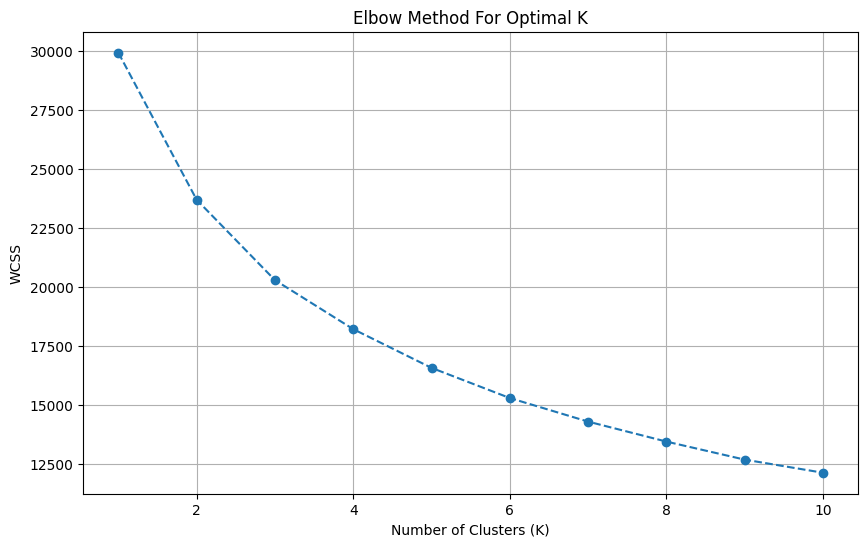

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 4 # Based on the elbow method
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster labels to the scaled DataFrame
df_scaled['Cluster'] = clusters

print(f"K-Means clustering performed with {optimal_k} clusters.")
print("Cluster distribution:")
display(df_scaled['Cluster'].value_counts().sort_index().to_frame())

K-Means clustering performed with 4 clusters.
Cluster distribution:


,count
Cluster,
0,1294
1,720
2,302
3,678


## **Stage 3:** Apply **TSNE** with 2 components (n_components = 2) and visualize the clusters (3 Marks)

Hint: Use Sklearns [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

**Note:** Produce a visualization with distinctly isolated clusters and It is not necessary to plot the centroids



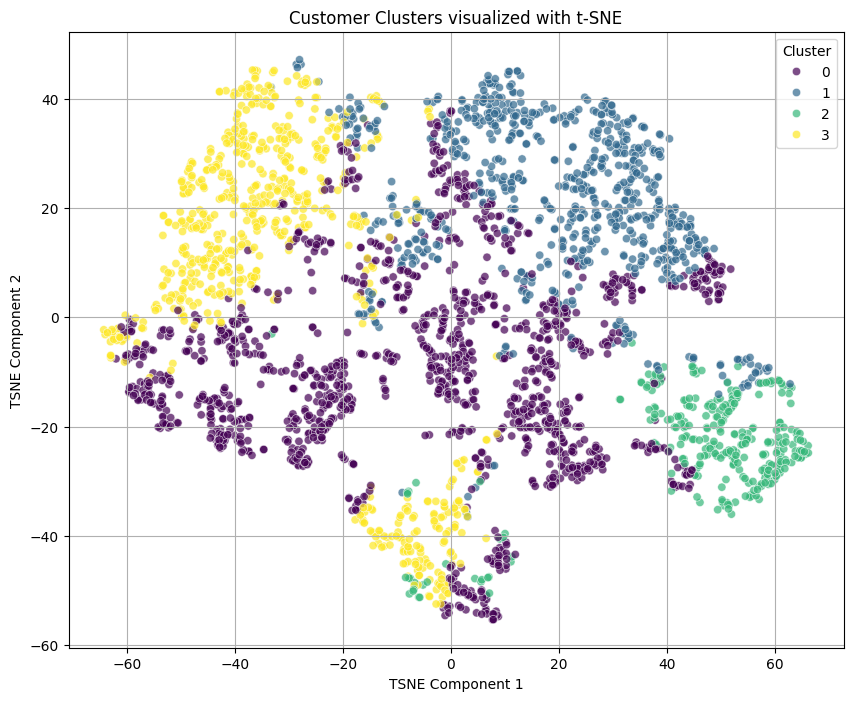

In [ ]:
# Initialize t-SNE with 2 components
ts_ne = TSNE(n_components=2, random_state=42)

# Fit and transform the scaled data (excluding the 'Cluster' column if it exists)
df_scaled_no_clusters = df_scaled.drop(columns=['Cluster'], errors='ignore')
tsne_features = ts_ne.fit_transform(df_scaled_no_clusters)

# Create a DataFrame for the t-SNE results
df_tsne = pd.DataFrame(data=tsne_features, columns=['TSNE1', 'TSNE2'])

# Add the cluster labels to the t-SNE DataFrame
df_tsne['Cluster'] = df_scaled['Cluster']

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='Cluster', palette='viridis', data=df_tsne,
    legend='full', alpha=0.7
)
plt.title('Customer Clusters visualized with t-SNE')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.grid(True)
plt.show()

## **Stage 4:** Insights for each cluster

#### **Stage 4(a)** (1 Mark):
- To understand the behavior of the customers from each cluster print the respective centroid point values obtained from the scaled dataframe
- Get the original representation of the scaled centroid points using [inverse_transformation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform) technique

In [ ]:
# Get the cluster centroids from the KMeans model
cluster_centroids_scaled = kmeans.cluster_centers_

# Inverse transform the scaled centroids to their original scale
cluster_centroids_original = scaler.inverse_transform(cluster_centroids_scaled)

# Create a DataFrame for better visualization
centroids_df = pd.DataFrame(
    data=cluster_centroids_original,
    columns=df_processed.columns
)

# Display the centroids
print("Centroid values for each cluster (original scale):")
display(centroids_df)

Centroid values for each cluster (original scale):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,882.040483,187.905363,48.856206,201.439701,0.220569,0.079341,2405.023184,516.230701,359.337528,0.008554,12.0
1,1189.341069,865.977417,487.680125,166.940132,0.809722,0.044213,3597.127525,984.662997,536.486625,0.009034,12.0
2,158.087055,501.206589,292.377947,164.066174,0.692881,0.034216,3446.026490,809.166607,166.383575,0.197020,12.0
3,2298.667448,158.618968,38.843496,1207.156945,0.141593,0.234390,4150.737463,1209.602927,742.835266,0.011686,12.0


#### **Stage 4(b)** (1 Mark):
- Report your observations in the form of text, about the customers based on the centroid points

Hint: If require use [clustermap](https://seaborn.pydata.org/generated/seaborn.clustermap.html)

### Observations from Cluster Centroids:

Looking at the `centroids_df`, which represents the average characteristics of customers in each cluster (in original scale), we can make the following observations:

*   **Cluster 0 (Low Spenders, Low Usage):**
    *   **BALANCE:** Relatively low.
    *   **PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE:** All very low.
    *   **PURCHASES_FREQUENCY:** Very low, indicating infrequent purchases.
    *   **CREDIT_LIMIT:** Low.
    *   **PAYMENTS, MINIMUM_PAYMENTS:** Low.
    *   **PRC_FULL_PAYMENT:** Very low.
    *   *Interpretation:* These customers appear to be new or inactive users, with minimal credit card
    activity, low balances, and infrequent purchases. They also rarely make full payments.

*   **Cluster 1 (Average Spenders, Mixed Usage):**
    *   **BALANCE:** Moderate.
    *   **PURCHASES:** Moderate, higher than Cluster 0 but lower than Cluster 2.
    *   **INSTALLMENTS_PURCHASES:** Moderate.
    *   **PURCHASES_FREQUENCY:** Moderate to high.
    *   **CASH_ADVANCE:** Relatively low.
    *   **CREDIT_LIMIT:** Moderate.
    *   **PAYMENTS, MINIMUM_PAYMENTS:** Moderate.
    *   **PRC_FULL_PAYMENT:** Moderate.
    *   *Interpretation:* This cluster represents typical users with a balanced usage pattern.
    They make a decent amount of purchases, some on installments, and maintain moderate balances and
     payments. They occasionally make full payments.

*   **Cluster 2 (High Purchasers, Responsible Payers):**
    *   **BALANCE:** Lowest among all clusters, suggesting they pay off their balance frequently.
    *   **PURCHASES, INSTALLMENTS_PURCHASES:** Highest values, indicating they are very active purchasers, especially for installment purchases.
    *   **PURCHASES_FREQUENCY:** Highest, meaning they purchase very frequently.
    *   **CASH_ADVANCE:** Very low.
    *   **CREDIT_LIMIT:** Moderate to high.
    *   **PAYMENTS:** Highest, indicating they pay off a large portion of their debt.
    *   **MINIMUM_PAYMENTS:** Low.
    *   **PRC_FULL_PAYMENT:** Highest, suggesting they often pay their full balance.
    *   *Interpretation:* These are high-value customers who use their credit cards extensively
    for purchases and are highly responsible with their payments, often paying in full.
     They rarely use cash advances.

*   **Cluster 3 (High Cash Advance Users, High Balances):**
    *   **BALANCE:** Highest among all clusters.
    *   **PURCHASES, INSTALLMENTS_PURCHASES:** Very low.
    *   **CASH_ADVANCE:** Highest by a significant margin.
    *   **CASH_ADVANCE_FREQUENCY:** Highest.
    *   **CREDIT_LIMIT:** Highest.
    *   **PAYMENTS, MINIMUM_PAYMENTS:** Highest, likely due to high balances.
    *   **PRC_FULL_PAYMENT:** Very low.
    *   *Interpretation:* This cluster consists of customers who heavily rely on cash advances
    and tend to carry high balances. They make very few purchases and rarely pay their full balance.
    They utilize their credit limit significantly for cash withdrawals.